In [2]:
import stcrpy
#print("✅ STCRpy version:", stcrpy.__version__)

# Fetch a real TCR:pMHC complex directly from the PDB (no local file needed!)
tcrs = stcrpy.fetch_TCRs("8gvb")          # Official example from STCRpy GitHub
print(f"✅ Loaded {len(tcrs)} TCR structure(s) from PDB 8gvb")

# Take the first (and usually only) TCR complex
tcr = tcrs[0]

print("TCR type:", tcr.get_TCR_type())
print("Bound to antigen:", tcr.is_bound())

# ------------------------------------------------------------------
# Calculate docking geometry (TCR → pMHC orientation)
# ------------------------------------------------------------------
geometry = tcr.calculate_docking_geometry(mode='rudolph')
print("\nDocking geometry (Rudolph method):")
for k, v in geometry.items():
    print(f"  {k}: {v}")

# Quick access to individual values
print(f"\nScanning angle: {tcr.get_scanning_angle():.2f}°")
print(f"Pitch angle:    {tcr.get_pitch_angle():.2f}°")

# ------------------------------------------------------------------
# Score the docking geometry (η score)
# ------------------------------------------------------------------
score = tcr.score_docking_geometry()
print(f"\nDocking geometry score (η): {score:.4f}  ← lower = more canonical")

Header could not be parsed

✅ Loaded 1 TCR structure(s) from PDB 8gvb
TCR type: abTCR
Bound to antigen: True

Docking geometry (Rudolph method):
  tcr_com: [None]
  mhc_com: [None]
  tcr_VA_com: [None]
  tcr_VB_com: [None]
  tcr_VA_cys_centroid: [array([ 8.936001,  9.841   , 14.488501], dtype=float32)]
  tcr_VB_cys_centroid: [array([17.1325   , -7.7314997, 27.1135   ], dtype=float32)]
  scanning_angle: 56.98940658569336
  pitch_angle: nan
  polarity: 0
  mode: rudolph

Scanning angle: 56.99°
Pitch angle:    0.38°


TypeError: TCRGeom.get_scanning_angle() got an unexpected keyword argument 'mode'

In [3]:
tcr.get_pitch_angle()

0.377539170585674

In [5]:
tcr = stcrpy.load_TCR("/projects/structures/clusters/HLA_A_align/ALSKGVHFV/aligned_9e7adc6b9c8348bbf11a5221e9f19d6166457015171612340c3f4a58998c662b.pdb")
geometry = tcr.calculate_docking_geometry(mode='rudolph')


/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 3344
  warnings.warn(


In [6]:
tcr.get_scanning_angle()

35.490204

In [7]:
tcr.get_pitch_angle()

1.2745934516757902

In [9]:
tcr.get_TCR_angles()

{'BA': -69.35133385820858,
 'BC1': 115.54028282784586,
 'AC1': 71.89386289915637,
 'BC2': 71.79639550390824,
 'AC2': 103.52549447120664,
 'dc': 17.34937715755989}

In [10]:
tcr.get_TCR_angles()

{'BA': -69.35133385820858,
 'BC1': 115.54028282784586,
 'AC1': 71.89386289915637,
 'BC2': 71.79639550390824,
 'AC2': 103.52549447120664,
 'dc': 17.34937715755989}

In [11]:
print("Pitch angle:", tcr.get_pitch_angle(mode='cys'), "°")

Pitch angle: 1.2745934516757902 °


In [13]:
print("Pitch angle:", tcr.get_pitch_angle(mode='com'), "°")

Pitch angle: 1.6642957519856687 °


In [25]:
tcr.score_docking_geometry()

TypeError: TCRGeom.get_scanning_angle() got an unexpected keyword argument 'mode'

In [16]:
tcr.geometry.get_scanning_angle(mode='com')

TypeError: TCRGeom.get_scanning_angle() got an unexpected keyword argument 'mode'

In [17]:
tcr.get_scanning_angle(mode='com')

57.42588286300914

In [19]:
geometry

{'tcr_com': [None],
 'mhc_com': [None],
 'tcr_VA_com': [None],
 'tcr_VB_com': [None],
 'tcr_VA_cys_centroid': [array([-11.97 ,  -8.356,  -9.514], dtype=float32)],
 'tcr_VB_cys_centroid': [array([ 11.0145   , -12.1814995,  -3.4915   ], dtype=float32)],
 'scanning_angle': 35.490204,
 'pitch_angle': nan,
 'polarity': 0,
 'mode': 'rudolph'}

In [1]:
def calc_angles(path):
    
    tcr = stcrpy.load_TCR(path)
    
    scanning = tcr.get_scanning_angle()
    pitch = tcr.get_pitch_angle()
    
    return {'scanning_angle': round(scanning, 4), 'pitch_angle': round(pitch, 4)}

In [29]:
calc_angles("/projects/structures/clusters/HLA_A_align/ALSKGVHFV/aligned_9e7adc6b9c8348bbf11a5221e9f19d6166457015171612340c3f4a58998c662b.pdb")

/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 3344
  warnings.warn(


{'scanning_angle': 35.4902, 'pitch_angle': 1.2746}

# Calc after generation

In [ ]:
import tqdm
import os
import numpy as np

structures = os.listdir('/projects/structures/clusters/HLA-A/')

res_dict_a = {}

for structure in tqdm.tqdm(structures):
    
    structure_path = f'/projects/structures/clusters/HLA-A/{structure}/{structure}_pmhc_oc/ranked_0.pdb'
    
    if os.path.exists(structure_path):
        
        try:
            res_dict_a[structure] = calc_angles(structure_path)
        except:
            print(structure)
            res_dict_a[structure] = {'scanning_angle': np.nan, 'pitch_angle': np.nan}

  0%|          | 7/9474 [00:07<2:42:12,  1.03s/it]

Generating symmetry mates to pair antigens.
ExecutiveSymExp-Error: No symmetry loaded!


/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/utils/symmetry_mates.py:29: UserWarning: No symmetry mates found for /projects/structures/clusters/HLA-A/853402e4720e59ac32743f4d704c270604421eab66964d38a9f6dbb431aadbcd/853402e4720e59ac32743f4d704c270604421eab66964d38a9f6dbb431aadbcd_pmhc_oc/ranked_0.pdb.
  warnings.warn(f"No symmetry mates found for {filename}.")
/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/TCRParser.py:1137: UserWarning: Symmetry mate generation failed with: 'NoneType' object is not iterable
  warnings.warn(f"Symmetry mate generation failed with: {str(e)}")
/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/TCR.py:327: UserWarning: No MHC found for TCR <TCR BA beta=B; alpha=A>. Docking geometry cannot be calcuated
  warnings.warn(
  0%|          | 8/9474 [00:09<3:38:31,  1.39s/it]

 Error-fetch: unable to load 'ranked_0'.
853402e4720e59ac32743f4d704c270604421eab66964d38a9f6dbb431aadbcd


  0%|          | 19/9474 [00:23<3:07:28,  1.19s/it]

...

 Error-fetch: unable to load 'ranked_0'.
6b2c7c88340422e7cbaff383fd3031aba3d942e4a78bad9a324d621f852ed156


 46%|████▌     | 4322/9474 [1:43:47<1:30:59,  1.06s/it]

cffbc1e4232797ae1ca88ff1ef03a6849d18dbcf296447e77d2b5a4cad6792b2


 46%|████▌     | 4329/9474 [1:43:56<1:51:46,  1.30s/it]

bf87970617077aa582efbfdb8a01c391ca33c3885d6f221a90016bf6d7b31949


# Parallel calc

In [2]:
import os
from multiprocessing import Pool, cpu_count
import tqdm
import numpy as np
import stcrpy


def calc_angles(path):
    
    tcr = stcrpy.load_TCR(path)
    
    scanning = tcr.get_scanning_angle()
    pitch = tcr.get_pitch_angle()
    
    return {'scanning_angle': round(scanning, 4), 'pitch_angle': round(pitch, 4)}


def process_structure(structure):
    """Worker function - must be top-level for pickling"""
    structure_path = f'/projects/structures/clusters/HLA-A/{structure}/{structure}_pmhc_oc/ranked_0.pdb'
    
    if not os.path.exists(structure_path):
        return structure, {'scanning_angle': 'not_exists', 'pitch_angle': 'not_exists'}
    
    try:
        result = calc_angles(structure_path)
        return structure, result
    except Exception as e:
        print(f"Error processing {structure}: {e}")
        return structure, {'scanning_angle': np.nan, 'pitch_angle': np.nan}


# ====================== MAIN CODE ======================

structures = os.listdir('/projects/structures/clusters/HLA-A/')

# Filter only directories that look valid (optional but recommended)
structures = [s for s in structures if os.path.isdir(f'/projects/structures/clusters/HLA-A/{s}')]

res_dict_a = {}

with Pool(processes=32) as pool:          # ← 32 processes
    # Use imap_unordered for better performance + tqdm progress bar
    results = list(tqdm.tqdm(
        pool.imap_unordered(process_structure, structures),
        total=len(structures),
        desc="Processing HLA-A structures"
    ))

# Convert list of tuples back to dictionary
for structure, result in results:
    res_dict_a[structure] = result

print(f"Completed: {len(res_dict_a)} structures processed")

Processing HLA-A structures:   0%|          | 0/9475 [00:00<?, ?it/s]

Generating symmetry mates to pair antigens.
Generating symmetry mates to pair antigens.
ExecutiveSymExp-Error: No symmetry loaded!
ExecutiveSymExp-Error: No symmetry loaded!
 Error-fetch: unable to load 'ranked_0'.
 Error-fetch: unable to load 'ranked_0'.

/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/utils/symmetry_mates.py:29: UserWarning: No symmetry mates found for /projects/structures/clusters/HLA-A/853402e4720e59ac32743f4d704c270604421eab66964d38a9f6dbb431aadbcd/853402e4720e59ac32743f4d704c270604421eab66964d38a9f6dbb431aadbcd_pmhc_oc/ranked_0.pdb.
  warnings.warn(f"No symmetry mates found for {filename}.")


/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/utils/symmetry_mates.py:29: UserWarning: No symmetry mates found for /projects/structures/clusters/HLA-A/118e425594df7f4994e31325da1bd896dffe349ee1ba05f7c39105b36c844165/118e425594df7f4994e31325da1bd896dffe349ee1ba05f7c39105b36c844165_pmhc_oc/ranked_0.pdb.
  warnings.warn(f"No symmetry mates found for {filename}.")
/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/TCRParser.py:1137: UserWarning: Symmetry mate generation failed with: 'NoneType' object is not iterable
  warnings.warn(f"Symmetry mate generation failed with: {str(e)}")
/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/TCRParser.py:1137: UserWarning: Symmetry mate generation failed with: 'NoneType' object is not iterable
  warnings.warn(f"Symmetry mate generation failed with: {str(e)}")
/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_

Error processing 118e425594df7f4994e31325da1bd896dffe349ee1ba05f7c39105b36c844165: 'abTCR' object has no attribute 'geometry'Error processing 853402e4720e59ac32743f4d704c270604421eab66964d38a9f6dbb431aadbcd: 'abTCR' object has no attribute 'geometry'


...

 Error-fetch: unable to load 'ranked_0'.


/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/utils/symmetry_mates.py:29: UserWarning: No symmetry mates found for /projects/structures/clusters/HLA-A/15922cb43c906800b43afd732e16c5cadb06daf2e4b6987c4328118ee9180c41/15922cb43c906800b43afd732e16c5cadb06daf2e4b6987c4328118ee9180c41_pmhc_oc/ranked_0.pdb.
  warnings.warn(f"No symmetry mates found for {filename}.")
/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/TCRParser.py:1137: UserWarning: Symmetry mate generation failed with: 'NoneType' object is not iterable
  warnings.warn(f"Symmetry mate generation failed with: {str(e)}")
/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/TCR.py:327: UserWarning: No MHC found for TCR <TCR BA beta=B; alpha=A>. Docking geometry cannot be calcuated
  warnings.warn(


Error processing 15922cb43c906800b43afd732e16c5cadb06daf2e4b6987c4328118ee9180c41: 'abTCR' object has no attribute 'geometry'


Processing HLA-A structures: 100%|██████████| 9475/9475 [23:17<00:00,  6.78it/s]


Completed: 9475 structures processed


In [6]:
structures = os.listdir('/projects/structures/clusters/HLA-B/')

# Filter only directories that look valid (optional but recommended)
structures = [s for s in structures if os.path.isdir(f'/projects/structures/clusters/HLA-B/{s}')]

res_dict_b = {}

def process_structure(structure):
    """Worker function - must be top-level for pickling"""
    structure_path = f'/projects/structures/clusters/HLA-B/{structure}/{structure}_pmhc_oc/ranked_0.pdb'
    
    if not os.path.exists(structure_path):
        return structure, {'scanning_angle': 'not_exists', 'pitch_angle': 'not_exists'}
    
    try:
        result = calc_angles(structure_path)
        return structure, result
    except Exception as e:
        print(f"Error processing {structure}: {e}")
        return structure, {'scanning_angle': np.nan, 'pitch_angle': np.nan}


with Pool(processes=32) as pool:          # ← 32 processes
    # Use imap_unordered for better performance + tqdm progress bar
    results = list(tqdm.tqdm(
        pool.imap_unordered(process_structure, structures),
        total=len(structures),
        desc="Processing HLA-A structures"
    ))

# Convert list of tuples back to dictionary
for structure, result in results:
    res_dict_b[structure] = result

print(f"Completed: {len(res_dict_b)} structures processed")

Processing HLA-A structures:   0%|          | 0/520 [00:00<?, ?it/s]

Generating symmetry mates to pair antigens.
Generating symmetry mates to pair antigens.
ExecutiveSymExp-Error: No symmetry loaded!
ExecutiveSymExp-Error: No symmetry loaded!
 Error-fetch: unable to load 'ranked_0'.


/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/utils/symmetry_mates.py:29: UserWarning: No symmetry mates found for /projects/structures/clusters/HLA-B/a07876909147bccaff3c22b0a2bc60804115ff0a4c3e7b3193a71c39f05b5245/a07876909147bccaff3c22b0a2bc60804115ff0a4c3e7b3193a71c39f05b5245_pmhc_oc/ranked_0.pdb.
  warnings.warn(f"No symmetry mates found for {filename}.")
/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/TCRParser.py:1137: UserWarning: Symmetry mate generation failed with: 'NoneType' object is not iterable
  warnings.warn(f"Symmetry mate generation failed with: {str(e)}")
/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_processing/TCR.py:327: UserWarning: No MHC found for TCR <TCR BA beta=B; alpha=A>. Docking geometry cannot be calcuated
  warnings.warn(


Error processing a07876909147bccaff3c22b0a2bc60804115ff0a4c3e7b3193a71c39f05b5245: 'abTCR' object has no attribute 'geometry'


Processing HLA-A structures:   0%|          | 1/520 [00:03<27:51,  3.22s/it]

...

Error processing a137dc02a7eba80dfbfb45c5c4d6d4d0551f05ec13685973c503f3e574244765: 'abTCR' object has no attribute 'geometry'


Processing HLA-A structures:  94%|█████████▍| 491/520 [01:12<00:02, 10.05it/s]/home/dluppov/.conda/envs/stcrpy_env/lib/python3.12/site-packages/stcrpy/tcr_geometry/TCRGeom.py:312: UserWarning: SG atom not found in IMGT residue number 104 of BA domain VA with chain ID A. Trying CA atom instead.
  warnings.warn(


Error processing 37d25a59816d6335c9fa64c55d067ecc21eb0d7ef0a46a800923dcac41e0d434: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.


Processing HLA-A structures: 100%|██████████| 520/520 [01:16<00:00,  6.79it/s]


Completed: 520 structures processed


In [7]:
res_dict_b

{'a07876909147bccaff3c22b0a2bc60804115ff0a4c3e7b3193a71c39f05b5245': {'scanning_angle': nan,
  'pitch_angle': nan},
 '43ba9b7f2899c42aeaad7ea3b597149c782645e0d1dd68738b81690136549cae': {'scanning_angle': nan,
  'pitch_angle': nan},
 '7450d2706f348a47b126995df347d9bbe23ebfd7832102785071ae7284f4ab7f': {'scanning_angle': 36.4904,
  'pitch_angle': 2.661},
 '177aa58b793c2dfb82f58bd651cf061c0bde68327f3f432a8da91e7e454c6ea8': {'scanning_angle': 28.8425,
  'pitch_angle': 2.1367},
 '0ef8375c29c5badf7064da150816b7e973468407787fee504ab41aa523a9f378': {'scanning_angle': 40.0026,
  'pitch_angle': 10.6918},
 '337609f19e59ff8838a90f2e92087299d13aed92443be375c1d582272e648a75': {'scanning_angle': 50.0794,
  'pitch_angle': 3.1761},
 '7e66a2e2ed36ed7d8d879bb1b3dabef9046c02c37053a05538e79ed115dcfeab': {'scanning_angle': 35.2856,
  'pitch_angle': 2.8341},
 '301b6f62c5845441492814028da7f0944d2d4bd123dc8037d83053e19142016e': {'scanning_angle': 33.2975,
  'pitch_angle': 6.4092},
 '3557cb790015e9cfd14935924784

In [8]:
structures = os.listdir('/projects/structures/clusters/HLA-E/')

# Filter only directories that look valid (optional but recommended)
structures = [s for s in structures if os.path.isdir(f'/projects/structures/clusters/HLA-E/{s}')]

res_dict_e = {}

def process_structure(structure):
    """Worker function - must be top-level for pickling"""
    structure_path = f'/projects/structures/clusters/HLA-E/{structure}/{structure}_pmhc_oc/ranked_0.pdb'
    
    if not os.path.exists(structure_path):
        return structure, {'scanning_angle': 'not_exists', 'pitch_angle': 'not_exists'}
    
    try:
        result = calc_angles(structure_path)
        return structure, result
    except Exception as e:
        print(f"Error processing {structure}: {e}")
        return structure, {'scanning_angle': np.nan, 'pitch_angle': np.nan}


with Pool(processes=32) as pool:          # ← 32 processes
    # Use imap_unordered for better performance + tqdm progress bar
    results = list(tqdm.tqdm(
        pool.imap_unordered(process_structure, structures),
        total=len(structures),
        desc="Processing HLA-E structures"
    ))

# Convert list of tuples back to dictionary
for structure, result in results:
    res_dict_e[structure] = result

print(f"Completed: {len(res_dict_e)} structures processed")

Processing HLA-E structures: 100%|██████████| 9/9 [00:02<00:00,  3.51it/s]

Completed: 9 structures processed


In [13]:
res_df = pd.DataFrame(res_dict_e | res_dict_a | res_dict_b).T
res_df

,scanning_angle,pitch_angle
b765d2c65831ba7d99fc49145b7291f56e0f8ca8d4f678c2b8b539be95861356,56.415699,4.2708
30545cbd3cc0a4290efdbd757c43d9bc20adce5a1a77c17ad27cfda05885b9fb,61.544701,6.9796
4c55d51c798c017d37736929b26903c977a070204f97bef91559c9053f997217,63.183399,4.4731
d335b806c6ad5c774744186f4bfd8fa03e47c510081712a39f4af5e985bcb4ae,83.028,15.497
5c48c8042cd6405830593d72e1ac3498a24a15a3a4d1d6b258d6add7f597f6bd,62.104,1.5959
...,...,...
1bd05cd41a5ba2c74881541fc53893d45a213dca58bff81e94965e4c592b4b6c,56.013199,4.7022
deb20d343061e9ecf702c69bbbcf350082a14d27334a278db20a7206627213b4,43.191502,13.3339
42e1563e03d2f039480d41c2bcb81c03ff66a51138ba969f7e95d919d15709c0,27.456301,0.0985
3a5a693bc617df3fda247fe5a5408d39ed23005043a29818ee0781babd2773ae,46.139198,3.561


In [16]:
res_df = res_df[res_df.scanning_angle != 'not_exists']
res_df.to_csv('tcr_angles.tsv', sep='\t')

# Plotting

In [1]:
import pandas as pd

In [2]:
res_df = pd.read_csv('tcr_angles.tsv', sep='\t', index_col=0)

In [3]:
data_rest = pd.concat([pd.read_csv('./quality_curr_structures.tsv', sep='\t', index_col=0), pd.read_csv('./contacts_curr_structures.tsv', sep='\t', index_col=0)], axis =1)
data_rest

,ranking_confidence,plddt,ptm,iptm,tcr-pmhc_iptm,0
fb95e51bc7d7e699457002ecb3cbbc9cce7b1628c3785096f3cbb920d41450eb,0.545186,88.507215,0.641245,0.521171,0.379790,8
5c48c8042cd6405830593d72e1ac3498a24a15a3a4d1d6b258d6add7f597f6bd,0.609681,90.394358,0.690247,0.589540,0.399869,13
4c55d51c798c017d37736929b26903c977a070204f97bef91559c9053f997217,0.604793,88.812546,0.683908,0.585014,0.452284,18
b765d2c65831ba7d99fc49145b7291f56e0f8ca8d4f678c2b8b539be95861356,0.730244,90.659333,0.781723,0.717374,0.706096,20
30545cbd3cc0a4290efdbd757c43d9bc20adce5a1a77c17ad27cfda05885b9fb,0.702323,91.617858,0.762058,0.687389,0.560634,17
...,...,...,...,...,...,...
8d758d286487ce18fd3b2b3d23d796aac6d25d0f4ab926bb19c0c0e80e730d2b,0.861143,94.614537,0.885557,0.855039,0.839061,12
c59816afa7843b3ae2093d064da816d743ce973523904f5fd98cff916c92d17c,0.869992,95.124419,0.892402,0.864390,0.840996,19
f4a15f4197af652eb6a3a8f7557d9776305e3856fecf7441fc68db0116e9d236,0.788360,92.823142,0.827428,0.778593,0.689536,18
f78501d4a54031b2a4eacc2b30e8927fea181f42535650ff745ccc1dbe78a251,0.815357,93.252800,0.852147,0.806159,0.765123,22


In [4]:
data_rest.rename(columns = {'0': 'num_contacts'}, inplace=True)

In [5]:
res_total = pd.concat([data_rest, res_df], axis=1)
res_total

,ranking_confidence,plddt,ptm,iptm,tcr-pmhc_iptm,num_contacts,scanning_angle,pitch_angle
fb95e51bc7d7e699457002ecb3cbbc9cce7b1628c3785096f3cbb920d41450eb,0.545186,88.507215,0.641245,0.521171,0.379790,8.0,74.034401,3.2980
5c48c8042cd6405830593d72e1ac3498a24a15a3a4d1d6b258d6add7f597f6bd,0.609681,90.394358,0.690247,0.589540,0.399869,13.0,62.104000,1.5959
4c55d51c798c017d37736929b26903c977a070204f97bef91559c9053f997217,0.604793,88.812546,0.683908,0.585014,0.452284,18.0,63.183399,4.4731
b765d2c65831ba7d99fc49145b7291f56e0f8ca8d4f678c2b8b539be95861356,0.730244,90.659333,0.781723,0.717374,0.706096,20.0,56.415699,4.2708
30545cbd3cc0a4290efdbd757c43d9bc20adce5a1a77c17ad27cfda05885b9fb,0.702323,91.617858,0.762058,0.687389,0.560634,17.0,61.544701,6.9796
...,...,...,...,...,...,...,...,...
fc95a9bf513f3135321649e26e57504a5a02bd768d4b15653e5d4bab281ee0f9,NaN,NaN,NaN,NaN,NaN,NaN,47.359901,2.5047
4c3a2212a92d827e1899935e9925d17fa53ccd787aaa17aceb3a8ce0b29e0d9d,NaN,NaN,NaN,NaN,NaN,NaN,50.493198,4.1212
b82ebc8425989a84b08a6f378c31367fbfbf3e1671e6010fe3c42aa1c7161a43,NaN,NaN,NaN,NaN,NaN,NaN,51.057800,2.4528
3d391121de5300ac6e895aabf1753355531fe7b8069d5e3d1e9c75944a9c2859,NaN,NaN,NaN,NaN,NaN,NaN,58.671101,3.5582


In [6]:
res_total = res_total.dropna(subset='ranking_confidence')
res_total

,ranking_confidence,plddt,ptm,iptm,tcr-pmhc_iptm,num_contacts,scanning_angle,pitch_angle
fb95e51bc7d7e699457002ecb3cbbc9cce7b1628c3785096f3cbb920d41450eb,0.545186,88.507215,0.641245,0.521171,0.379790,8.0,74.034401,3.2980
5c48c8042cd6405830593d72e1ac3498a24a15a3a4d1d6b258d6add7f597f6bd,0.609681,90.394358,0.690247,0.589540,0.399869,13.0,62.104000,1.5959
4c55d51c798c017d37736929b26903c977a070204f97bef91559c9053f997217,0.604793,88.812546,0.683908,0.585014,0.452284,18.0,63.183399,4.4731
b765d2c65831ba7d99fc49145b7291f56e0f8ca8d4f678c2b8b539be95861356,0.730244,90.659333,0.781723,0.717374,0.706096,20.0,56.415699,4.2708
30545cbd3cc0a4290efdbd757c43d9bc20adce5a1a77c17ad27cfda05885b9fb,0.702323,91.617858,0.762058,0.687389,0.560634,17.0,61.544701,6.9796
...,...,...,...,...,...,...,...,...
8d758d286487ce18fd3b2b3d23d796aac6d25d0f4ab926bb19c0c0e80e730d2b,0.861143,94.614537,0.885557,0.855039,0.839061,12.0,37.784599,5.7716
c59816afa7843b3ae2093d064da816d743ce973523904f5fd98cff916c92d17c,0.869992,95.124419,0.892402,0.864390,0.840996,19.0,46.328899,7.1343
f4a15f4197af652eb6a3a8f7557d9776305e3856fecf7441fc68db0116e9d236,0.788360,92.823142,0.827428,0.778593,0.689536,18.0,47.352798,3.8434
f78501d4a54031b2a4eacc2b30e8927fea181f42535650ff745ccc1dbe78a251,0.815357,93.252800,0.852147,0.806159,0.765123,22.0,46.741199,3.5940


In [7]:
res_total.to_csv('./total_res.tsv', sep='\t')

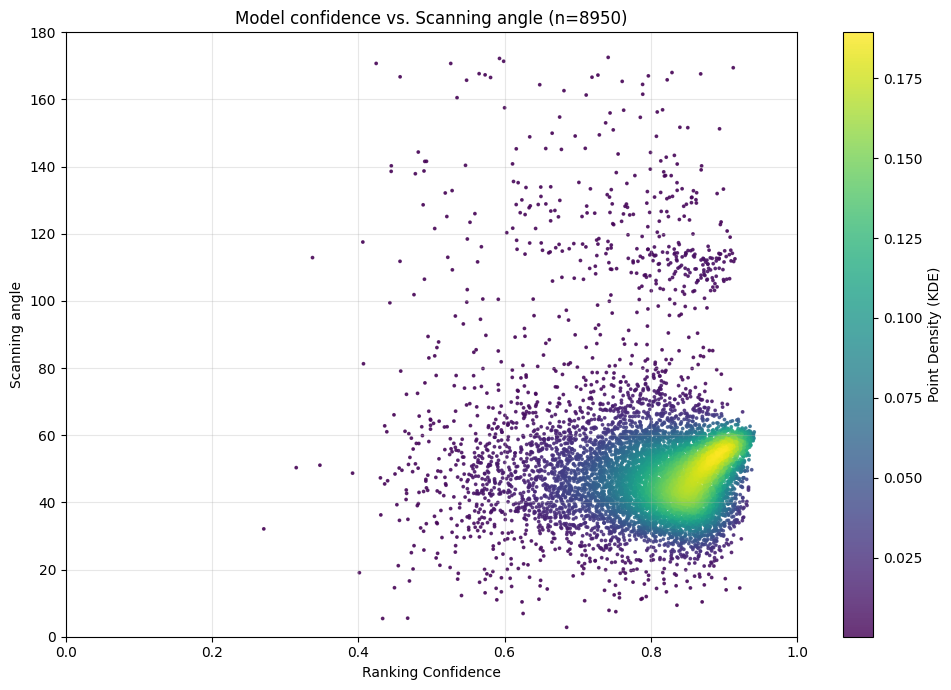

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde


total_data = res_total.copy()

total_data = total_data.dropna(subset='scanning_angle')

x = total_data['ranking_confidence'].values
y = total_data['scanning_angle'].astype(float).values

# Calculate 2D kernel density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, c=z, s=3, cmap='viridis', alpha=0.8)   # s=3 or s=1 for tiny points
plt.colorbar(label='Point Density (KDE)')
plt.xlabel('Ranking Confidence')
plt.ylabel('Scanning angle')
plt.title(f'Model confidence vs. Scanning angle (n={len(x)})')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 180)
plt.tight_layout()
#plt.savefig('confidence_vs_contacts.png', dpi=300)
plt.show()

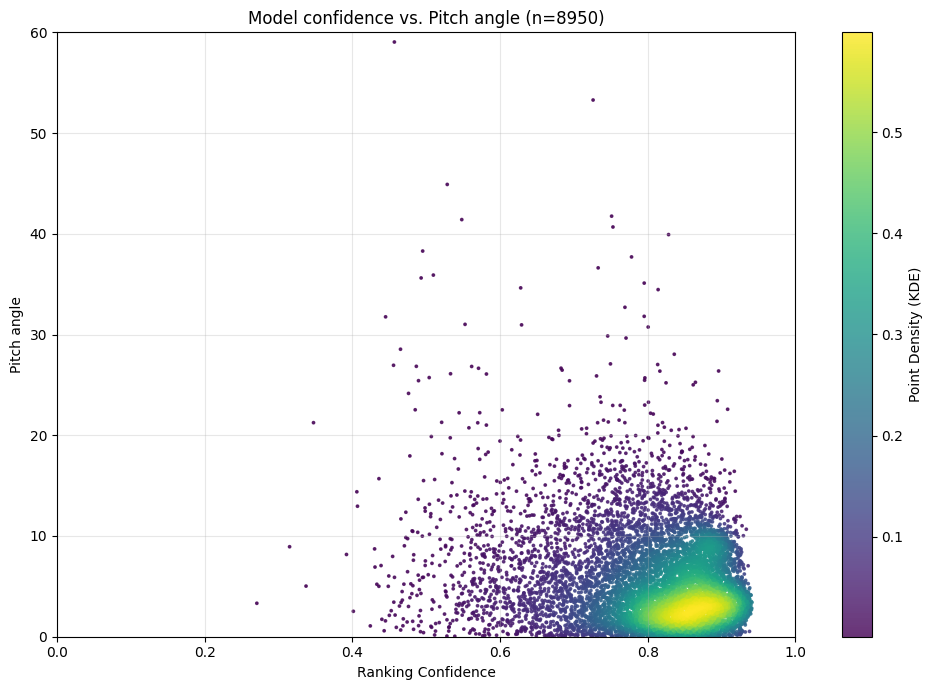

In [8]:
total_data = res_total.copy()

total_data = total_data.dropna(subset='scanning_angle')

x = total_data['ranking_confidence'].values
y = total_data['pitch_angle'].astype(float).values

# Calculate 2D kernel density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, c=z, s=3, cmap='viridis', alpha=0.8)   # s=3 or s=1 for tiny points
plt.colorbar(label='Point Density (KDE)')
plt.xlabel('Ranking Confidence')
plt.ylabel('Pitch angle')
plt.title(f'Model confidence vs. Pitch angle (n={len(x)})')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 60)
plt.tight_layout()
#plt.savefig('confidence_vs_contacts.png', dpi=300)
plt.show()

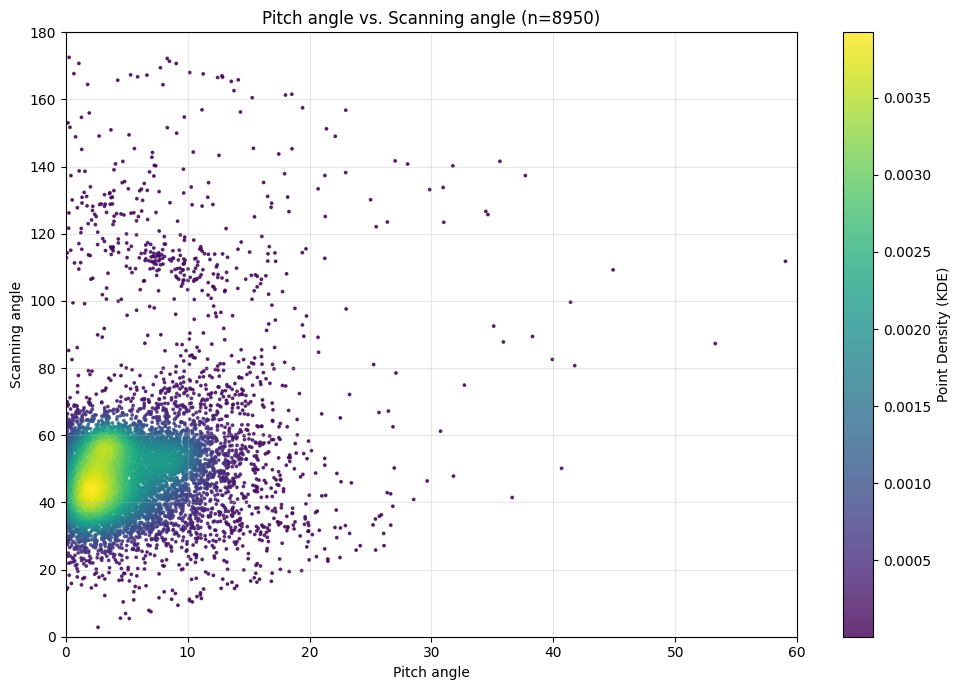

In [36]:
x = total_data['pitch_angle'].astype(float).values
y = total_data['scanning_angle'].astype(float).values

# Calculate 2D kernel density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, c=z, s=3, cmap='viridis', alpha=0.8)   # s=3 or s=1 for tiny points
plt.colorbar(label='Point Density (KDE)')
plt.xlabel('Pitch angle')
plt.ylabel('Scanning angle')
plt.title(f'Pitch angle vs. Scanning angle (n={len(x)})')
plt.grid(True, alpha=0.3)
plt.xlim(0, 60)
plt.ylim(0, 180)

plt.tight_layout()
#plt.savefig('confidence_vs_contacts.png', dpi=300)
plt.show()

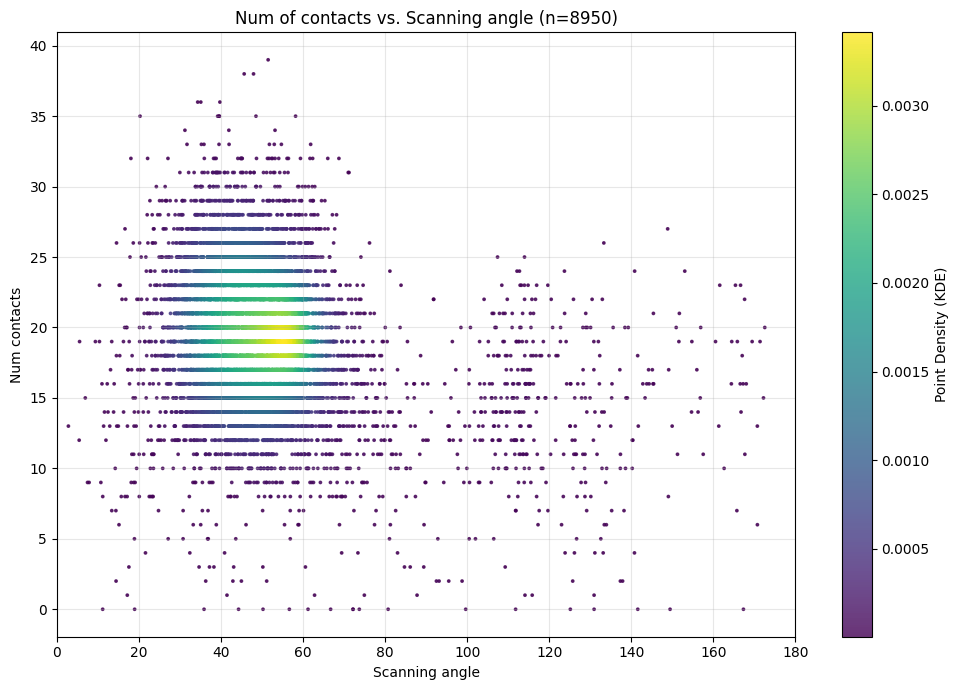

In [42]:
x = total_data['scanning_angle'].astype(float).values
y = total_data['num_contacts'].astype(float).values

# Calculate 2D kernel density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, c=z, s=3, cmap='viridis', alpha=0.8)   # s=3 or s=1 for tiny points
plt.colorbar(label='Point Density (KDE)')
plt.ylabel('Num contacts')
plt.xlabel('Scanning angle')
plt.title(f'Num of contacts vs. Scanning angle (n={len(x)})')
plt.grid(True, alpha=0.3)
#plt.xlim(0, 60)
plt.xlim(0, 180)

plt.tight_layout()
#plt.savefig('confidence_vs_contacts.png', dpi=300)
plt.show()

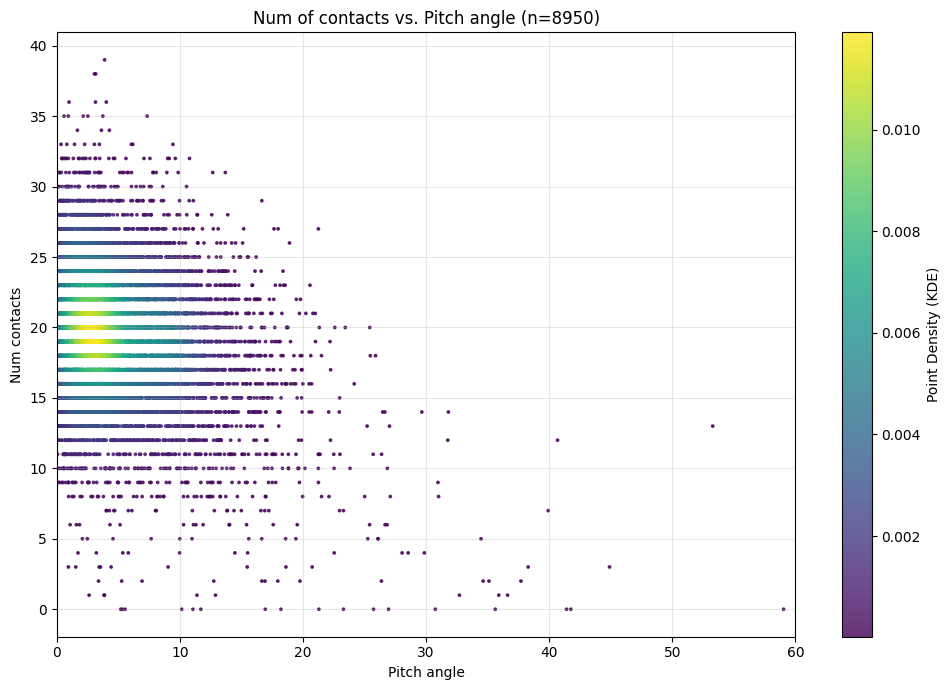

In [44]:
x = total_data['pitch_angle'].astype(float).values
y = total_data['num_contacts'].astype(float).values

# Calculate 2D kernel density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, c=z, s=3, cmap='viridis', alpha=0.8)   # s=3 or s=1 for tiny points
plt.colorbar(label='Point Density (KDE)')
plt.ylabel('Num contacts')
plt.xlabel('Pitch angle')
plt.title(f'Num of contacts vs. Pitch angle (n={len(x)})')
plt.grid(True, alpha=0.3)
#plt.xlim(0, 60)
plt.xlim(0, 60)

plt.tight_layout()
#plt.savefig('confidence_vs_contacts.png', dpi=300)
plt.show()